# 用現成套件做前處理 — Python 版

主 notebook `rock_raman_tutorial.ipynb` 裡的 ALS、Savitzky–Golay、SNV 都是手寫的，
目的是讓你看見每一步在算什麼。實務上你會用套件：

| 步驟 | 套件 | 函式 |
|---|---|---|
| 基線 | [`pybaselines`](https://pybaselines.readthedocs.io/) | `whittaker.asls`、`whittaker.arpls`、`polynomial.imodpoly` … 50 種以上 |
| 平滑／導數 | `scipy.signal` | `savgol_filter` |
| SNV | 沒有套件 | 兩行 numpy 就寫完了，不需要 |

這份 notebook 把手寫版與套件版擺在一起跑，逐項比對數字，
並且把**三個預設值會咬人的地方**標出來 —— 這三個坑在 R 的
`baseline` / `prospectr` 上也一樣（見 `r/preprocess_packages.R`）。

```bash
pip install pybaselines numpy scipy pandas matplotlib
```

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.sparse import diags, csc_matrix
from scipy.sparse.linalg import spsolve

import pybaselines
from pybaselines.whittaker import asls, arpls
from pybaselines.polynomial import imodpoly

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.unicode_minus": False})
from matplotlib import font_manager
for _f in ["Noto Sans CJK TC", "Noto Sans CJK JP", "Noto Sans CJK SC",
           "Microsoft JhengHei", "PingFang TC", "Heiti TC", "SimHei"]:
    if any(_f == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.sans-serif"] = [_f] + plt.rcParams["font.sans-serif"]; break

print("pybaselines", pybaselines.__version__)

pybaselines 1.2.1


In [2]:
d   = pd.read_csv("../data/rock_raman_2class_raw.csv")
wn  = np.array([float(c) for c in d.columns[2:]])
X   = d.iloc[:, 2:].to_numpy(float)
ids = d.iloc[:, 0].tolist()
STEP = float(np.diff(wn).mean())
print(f"X = {X.shape},  wn {wn[0]:.1f}-{wn[-1]:.1f},  mean step {STEP:.4f} cm-1")

X = (10, 664),  wn 150.0-1798.5,  mean step 2.4863 cm-1


## 1. 手寫版（從主 notebook 抄過來，當比對基準）

In [3]:
def D2(m):
    e = np.ones(m)
    return diags([e[:-2], -2*e[:-1], e], [0, 1, 2], shape=(m-2, m)).tocsc()

def als_hand(y, lam=1e4, p=0.01, niter=15):
    # 本教材的手寫 ALS：固定跑滿 niter，等號落在基線上的點算「低於」。
    m = len(y); DD = lam * (D2(m).T @ D2(m)); w = np.ones(m)
    for _ in range(niter):
        z = spsolve(csc_matrix(diags(w)) + DD, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

def sg_hand(y, w=9, poly=3, deriv=0):
    # 手寫 SG：兩端複製端點來補，輸出長度 = 輸入長度。
    hw = (w - 1) // 2; k = np.arange(-hw, hw + 1)
    A = np.vander(k, poly + 1, increasing=True)
    C = np.linalg.solve(A.T @ A, A.T)
    cf = C[deriv] * float(np.prod(range(1, deriv + 1)) or 1)
    yp = np.r_[np.repeat(y[0], hw), y, np.repeat(y[-1], hw)]
    return np.array([cf @ yp[i:i+w] for i in range(len(y))])

def snv_hand(Y):
    return (Y - Y.mean(1, keepdims=True)) / Y.std(1, ddof=1, keepdims=True)

## 2. 基線：`pybaselines.whittaker.asls`

`asls` 就是 Eilers & Boelens 的 AsLS，跟手寫版同一個演算法。參數對照：

| 手寫版 | `asls` | 說明 |
|---|---|---|
| `lam=1e4` | `lam=1e4` | **同樣是線性的**，不是 log10 |
| `p=0.01` | `p=0.01` | 一樣 |
| `niter=15` | `max_iter=15, tol=0` | 手寫版沒有收斂判準，要把 `tol` 設 0 才會真的跑滿 |

參數對齊之後，兩邊應該吻合到浮點數精度。

In [4]:
mx = 0.0
for y in X:
    zh = als_hand(y, 1e4, 0.01, 15)
    zp, _ = asls(y, lam=1e4, p=0.01, max_iter=15, tol=0)
    mx = max(mx, np.abs(zh - zp).max())

rng = X[0].max() - X[0].min()
print(f"max |hand - pybaselines|  over all 10 spectra : {mx:.3e}")
print(f"signal range of spectrum 1                    : {rng:.1f} counts")
print(f"relative                                      : {mx/rng:.2e}")
print("\n-> 同一個演算法，參數對齊，數字就一樣。")

max |hand - pybaselines|  over all 10 spectra : 7.015e-09
signal range of spectrum 1                    : 271.0 counts
relative                                      : 2.59e-11

-> 同一個演算法，參數對齊，數字就一樣。


### 坑 #1：`lam` 的預設值是 `1e6`，不是你手寫的 `1e4`

而且 —— 這是最容易踩的 —— **R 的 `baseline::baseline.als` 的 `lambda` 是 log10**：
`lambda = 6` 代表 10⁶。三邊的慣例是：

| | 參數名 | 預設 | 意義 |
|---|---|---|---|
| 手寫 | `lam` | 1e4 | 線性 |
| `pybaselines.asls` | `lam` | **1e6** | 線性 |
| `baseline::baseline.als` | `lambda` | **6** | **log10 → 10⁶** |

把手寫的 `1e4` 直接填進 R 的 `lambda`，你要求的是 10¹⁰⁰⁰⁰。

In [5]:
def als_R(y, lambda_log10=6, p=0.05, maxit=20):
    # baseline::baseline.als 的複刻（照 CRAN 原始碼）。lambda 是 10 的次方。
    m = len(y); DD = (10.0**lambda_log10) * (D2(m).T @ D2(m)); w = np.ones(m)
    for _ in range(maxit):
        z = spsolve(csc_matrix(diags(w)) + DD, w * y)
        w_old = w; w = p * (y > z) + (1 - p) * (y < z)
        if np.sum(w_old != w) == 0: break
    return z

y = X[0]
zh    = als_hand(y)
zdef, _ = asls(y)                  # pybaselines 預設 lam=1e6, p=0.01, max_iter=50, tol=1e-3
zR6   = als_R(y, 6, 0.05, 20)      # baseline::als 預設
zR4   = als_R(y, 4, 0.01, 20)      # lambda=4 -> 1e4，與手寫對齊

rmsd = lambda a, b: float(np.sqrt(np.mean((a-b)**2)))
print(f"hand(1e4) vs pybaselines 預設 lam=1e6        : RMSD {rmsd(zh, zdef):7.2f} counts")
print(f"hand(1e4) vs baseline::als lambda=6, p=.05   : RMSD {rmsd(zh, zR6):7.2f} counts")
print(f"hand(1e4) vs baseline::als lambda=4, p=.01   : RMSD {rmsd(zh, zR4):7.2f} counts   <- 對齊了")

def peak(z, c=1008, tol=8):
    j = (wn > c-tol) & (wn < c+tol); return (y - z)[j].max()
print("\n1008 cm-1 峰高：")
for nm, z in [("hand lam=1e4", zh), ("pybaselines 預設 lam=1e6", zdef),
              ("baseline::als lambda=6 p=.05", zR6), ("baseline::als lambda=4 p=.01", zR4)]:
    print(f"  {nm:32s} {peak(z):8.1f}")
print(f"\n-> 預設值差了 {100*(peak(zh)-peak(zR6))/peak(zh):.1f}%。峰高要拿來做半定量的話，這不是小數字。")

hand(1e4) vs pybaselines 預設 lam=1e6        : RMSD    3.90 counts
hand(1e4) vs baseline::als lambda=6, p=.05   : RMSD    6.64 counts
hand(1e4) vs baseline::als lambda=4, p=.01   : RMSD    0.00 counts   <- 對齊了

1008 cm-1 峰高：
  hand lam=1e4                        143.1
  pybaselines 預設 lam=1e6              141.5
  baseline::als lambda=6 p=.05        134.5
  baseline::als lambda=4 p=.01        143.1

-> 預設值差了 6.0%。峰高要拿來做半定量的話，這不是小數字。


### `pybaselines` 值得一試的其他方法

AsLS 只是 50 幾種裡的一種。拉曼的螢光背景常用的還有 **arPLS**（權重自動調，
不必猜 `p`）與 **imodPoly**（迭代多項式，對緩慢彎曲的背景很穩）。

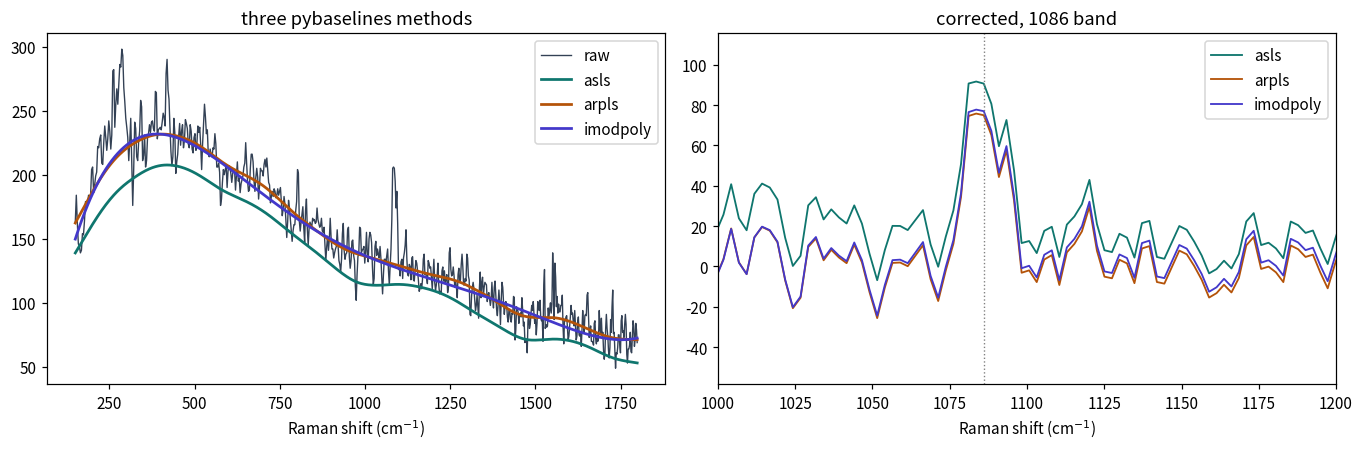

asls       1086 峰高 =    91.7
arpls      1086 峰高 =    75.8
imodpoly   1086 峰高 =    77.7


In [6]:
y = X[ids.index("marble4")] if "marble4" in ids else X[8]
b_asls,  _ = asls(y, lam=1e4, p=0.01)
b_arpls, _ = arpls(y, lam=1e5)
b_imod,  _ = imodpoly(y, x_data=wn, poly_order=5)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].plot(wn, y, color="#334155", lw=.9, label="raw")
for nm, b, c in [("asls", b_asls, "#0F766E"), ("arpls", b_arpls, "#B45309"),
                 ("imodpoly", b_imod, "#4338CA")]:
    ax[0].plot(wn, b, lw=1.8, label=nm, color=c)
ax[0].legend(); ax[0].set_title("three pybaselines methods"); ax[0].set_xlabel("Raman shift (cm$^{-1}$)")
for nm, b, c in [("asls", b_asls, "#0F766E"), ("arpls", b_arpls, "#B45309"),
                 ("imodpoly", b_imod, "#4338CA")]:
    ax[1].plot(wn, y - b, lw=1.2, label=nm, color=c)
ax[1].set_xlim(1000, 1200); ax[1].axvline(1086, color="grey", ls=":", lw=.9)
ax[1].legend(); ax[1].set_title("corrected, 1086 band"); ax[1].set_xlabel("Raman shift (cm$^{-1}$)")
plt.tight_layout(); plt.show()

for nm, b in [("asls", b_asls), ("arpls", b_arpls), ("imodpoly", b_imod)]:
    j = (wn > 1078) & (wn < 1094)
    print(f"{nm:10s} 1086 峰高 = {(y-b)[j].max():7.1f}")

## 3. 平滑：`scipy.signal.savgol_filter`

內部的係數三邊完全一樣，**差別只在邊界**：

| | 邊界怎麼處理 | 輸出長度 |
|---|---|---|
| 手寫 | 複製端點來補 | 664（不變） |
| `savgol_filter`（預設 `mode='interp'`） | 端點用多項式外推 | 664（不變） |
| `prospectr::savitzkyGolay` | **直接砍掉** | 656（少 w−1） |

In [7]:
def sg_prospectr(y, w=9, poly=3, m=0, delta=None):
    # prospectr::savitzkyGolay 的複刻：valid convolution，兩端各砍 (w-1)/2。
    hw = (w - 1) // 2; k = np.arange(-hw, hw + 1)
    A = np.vander(k, poly + 1, increasing=True)
    C = np.linalg.solve(A.T @ A, A.T)
    cf = C[m] * float(np.prod(range(1, m + 1)) or 1)
    o = np.convolve(y, cf[::-1], mode="valid")
    return o / delta**m if (delta and m) else o

y = X[0]; g = 4
h  = sg_hand(y)
s  = savgol_filter(y, 9, 3)
pr = sg_prospectr(y)

print(f"長度   hand {len(h)}   scipy {len(s)}   prospectr {len(pr)}   (輸入 {len(y)})")
print(f"內部   hand vs scipy      max diff {np.abs(h[g:-g]-s[g:-g]).max():.3e}")
print(f"內部   hand vs prospectr  max diff {np.abs(h[g:-g]-pr).max():.3e}")
print(f"內部   scipy vs prospectr max diff {np.abs(s[g:-g]-pr).max():.3e}")
print(f"\n邊界   第 1 點  hand {h[0]:8.2f}   scipy {s[0]:8.2f}   差 {abs(h[0]-s[0]):.2f}")
print(f"       第 2 點  hand {h[1]:8.2f}   scipy {s[1]:8.2f}   差 {abs(h[1]-s[1]):.2f}")
print("\n-> 內部到 1e-13，邊界差好幾個 count。做峰位鑑定時邊界通常不重要，")
print("   但如果你的診斷峰剛好靠近光譜端點，這就會變成真的問題。")

長度   hand 664   scipy 664   prospectr 656   (輸入 664)
內部   hand vs scipy      max diff 3.411e-13
內部   hand vs prospectr  max diff 5.684e-14
內部   scipy vs prospectr max diff 3.411e-13

邊界   第 1 點  hand   134.70   scipy   141.51   差 6.80
       第 2 點  hand   128.90   scipy   130.44   差 1.54

-> 內部到 1e-13，邊界差好幾個 count。做峰位鑑定時邊界通常不重要，
   但如果你的診斷峰剛好靠近光譜端點，這就會變成真的問題。


### 坑 #2：換成 `prospectr` 之後，波數軸要跟著砍

`savgol_filter` 不會改長度，所以 Python 這邊比較不容易踩。
但只要你在 R 那邊用了 `prospectr`，或在 Python 用 `mode='valid'` 自己捲積，
`X` 少了 8 欄而 `wn` 還是 664 個 —— VIP 表對回波數時就會**整條位移 4 個點**，
在這份資料上是 **12.0 cm⁻¹**。這足以讓你把 1008 認成 1020。

In [8]:
wn_sg = wn[g:-g]
print(f"wn {len(wn)} -> wn_sg {len(wn_sg)}   ({wn[0]:.1f}-{wn[-1]:.1f} -> {wn_sg[0]:.1f}-{wn_sg[-1]:.1f})")
print(f"如果忘了砍，第 i 欄會被標成 wn[i] 而不是 wn_sg[i]，位移 = {wn[g]-wn[0]:.1f} cm-1")

wn 664 -> wn_sg 656   (150.0-1798.5 -> 162.0-1790.3)
如果忘了砍，第 i 欄會被標成 wn[i] 而不是 wn_sg[i]，位移 = 12.0 cm-1


### 坑 #3：導數的單位

`savgol_filter(..., deriv=1)` 預設 `delta=1.0`，算出來是「**每一個資料點**」的變化量。
要變成「每 cm⁻¹」必須給 `delta`。R 的 `prospectr` 對應參數叫 `delta.wav`。

分類不受影響（全體同乘一個常數），但只要你要**報數值**，或跟別人的資料比，就一定要給。

In [9]:
d_idx = savgol_filter(y, 9, 3, deriv=1)                # delta = 1
d_wav = savgol_filter(y, 9, 3, deriv=1, delta=STEP)    # delta = 2.4863
print(f"delta=1      max|d1| = {np.abs(d_idx).max():.4f}   (每一點)")
print(f"delta={STEP:.4f} max|d1| = {np.abs(d_wav).max():.4f}   (每 cm-1)")
print(f"比值 = {np.abs(d_idx).max()/np.abs(d_wav).max():.4f}   = mean step")

pr1 = sg_prospectr(y, m=1, delta=STEP)
print(f"\nprospectr(delta.wav) vs scipy(delta) 內部 max diff = {np.abs(pr1 - d_wav[g:-g]).max():.3e}")
print("-> 兩邊定義一致。")

delta=1      max|d1| = 49.9192   (每一點)
delta=2.4863 max|d1| = 20.0773   (每 cm-1)
比值 = 2.4863   = mean step

prospectr(delta.wav) vs scipy(delta) 內部 max diff = 1.066e-14
-> 兩邊定義一致。


## 4. SNV：這一個沒有坑

`prospectr::standardNormalVariate` 的分母是 **n−1**（跟 R 的 `sd()`、
跟 numpy 的 `ddof=1` 一樣）。手寫版如果寫 `Y.std(1)`（numpy 預設 `ddof=0`）就會差一點點。

In [10]:
A = snv_hand(X)                                            # ddof=1
B = (X - X.mean(1, keepdims=True))
B = B / np.sqrt((B**2).sum(1, keepdims=True) / (X.shape[1] - 1))   # prospectr 的算法
C = (X - X.mean(1, keepdims=True)) / X.std(1, ddof=0, keepdims=True)  # numpy 預設

print(f"hand(ddof=1) vs prospectr : max diff {np.abs(A-B).max():.3e}   <- 完全一樣")
print(f"hand(ddof=1) vs ddof=0    : max diff {np.abs(A-C).max():.3e}")
print(f"                            比值 sqrt(n/(n-1)) = {np.sqrt(X.shape[1]/(X.shape[1]-1)):.6f}")
print("\n-> 664 個點的時候差 0.075%，不影響分類；但如果你只取 20 個波數就會開始有感。")

hand(ddof=1) vs prospectr : max diff 0.000e+00   <- 完全一樣
hand(ddof=1) vs ddof=0    : max diff 5.559e-03
                            比值 sqrt(n/(n-1)) = 1.000754

-> 664 個點的時候差 0.075%，不影響分類；但如果你只取 20 個波數就會開始有感。


## 5. 該用手寫還是套件？

**用套件。** 這份教材手寫，是為了讓你看見演算法；正式分析用套件，理由是：

1. **別人可以重現**。`asls(y, lam=1e4, p=0.01)` 一行就把方法交代完了，
   你的手寫函式別人得逐行讀。
2. **邊界情況已經處理過**。NaN、全零的譜、病態矩陣 —— 套件被幾千個人踩過。
3. **方法多**。`pybaselines` 有 50 幾種基線演算法，換一種只要改函式名。

但是 —— **投稿時務必寫清楚版本與參數**：

> Baselines were removed with the AsLS algorithm (`pybaselines` 1.2.1,
> `whittaker.asls`, `lam` = 1×10⁴, `p` = 0.01, 15 iterations); spectra were then
> smoothed with a Savitzky–Golay filter (`scipy.signal.savgol_filter`,
> window 9, polynomial order 3) and normalised with SNV.

只寫「ALS baseline correction was applied」等於什麼都沒說 —— 光是 `lam`
一個參數在三個常見實作裡就有兩種慣例。

## 6. 對照

- R 版：`r/preprocess_packages.R`（`baseline` + `prospectr`，同樣逐項比對）
- 手寫版與完整分析：`rock_raman_tutorial.ipynb`
- 教材本體：`index.html` 第七篇